### Author: Trịnh Thái Gia Bảo
# Lab 2: Làm sạch dữ liệu, phân tích khám phá và chuẩn bị đặc trưng
**Bộ dữ liệu:** UCI Diabetes 130-US Hospitals (101 766 bản ghi, 50 cột)

**Tình huống bài toán:** Một văn phòng y tế thành phố nhận được bộ dữ liệu sàng lọc lộn xộn từ nhiều phòng khám. Trước khi có thể tin tưởng bất kỳ mô hình học máy nào, dữ liệu cần được làm sạch, chuẩn hóa và khám phá.

**Mục tiêu (Target):** `readmitted` – Bệnh nhân có tái nhập viện hay không (<30 ngày, >30 ngày, hoặc No).

In [ ]:
# %pip install pandas matplotlib
#%pip install scikit-learn
#%pip install seaborn numpy

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Cấu hình hiển thị
pd.set_option("display.max_columns", 55)
pd.set_option("display.max_rows", 60)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)

print("Import thành công!")

Import thành công!


---
## Bước 1: Kiểm toán dữ liệu thô (Data Audit)
> Liệt kê mọi cột, đếm giá trị thiếu và xác định mục nhập đáng nghi.

In [5]:
# 1.1 Đọc dữ liệu – ký tự "?" trong CSV đại diện cho giá trị thiếu
DATA_DIR = Path("data")
raw_df = pd.read_csv(DATA_DIR / "diabetic_data_raw.csv", na_values="?", low_memory=False)
variables_df = pd.read_csv(DATA_DIR / "diabetes_variables.csv")

print(f"Kích thước dữ liệu thô: {raw_df.shape[0]:,} dòng × {raw_df.shape[1]} cột")
raw_df.head(3)

Kích thước dữ liệu thô: 101,766 dòng × 50 cột


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


In [6]:
# 1.2 Thông tin tổng quan
raw_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
# 1.3 Đếm giá trị thiếu theo từng cột
missing_before = raw_df.isnull().sum()
missing_pct = (missing_before / len(raw_df) * 100).round(2)

missing_report = pd.DataFrame({
    "Số lượng thiếu": missing_before,
    "Tỷ lệ (%)": missing_pct
}).query("`Số lượng thiếu` > 0").sort_values("Tỷ lệ (%)", ascending=False)

print("=" * 50)
print("BÁO CÁO GIÁ TRỊ THIẾU TRƯỚC KHI LÀM SẠCH")
print("=" * 50)
missing_report

BÁO CÁO GIÁ TRỊ THIẾU TRƯỚC KHI LÀM SẠCH


,Số lượng thiếu,Tỷ lệ (%)
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


In [8]:
# 1.4 Kiểm tra dòng trùng lặp
dup_encounter = raw_df["encounter_id"].duplicated().sum()
dup_patient = raw_df["patient_nbr"].duplicated().sum()
dup_full = raw_df.duplicated().sum()

print(f"Trùng encounter_id  : {dup_encounter}")
print(f"Trùng patient_nbr   : {dup_patient:,} (bệnh nhân có nhiều lần nhập viện)")
print(f"Trùng toàn bộ dòng  : {dup_full}")

Trùng encounter_id  : 0
Trùng patient_nbr   : 30,248 (bệnh nhân có nhiều lần nhập viện)
Trùng toàn bộ dòng  : 0


In [9]:
# 1.5 Phát hiện mục nhập đáng nghi
print("--- Gender ---")
print(raw_df["gender"].value_counts())
print()
print("--- Age ---")
print(raw_df["age"].value_counts().sort_index())
print()
# Cột gần như chỉ có 1 giá trị (near-zero variance)
print("--- Các cột gần như không đổi (≤ 1 giá trị ngoài 'No') ---")
for col in raw_df.select_dtypes("object").columns:
    vc = raw_df[col].value_counts()
    if len(vc) <= 2 and vc.iloc[0] / len(raw_df) > 0.999:
        print(f"  {col:30s}  →  {vc.to_dict()}")

--- Gender ---
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

--- Age ---
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

--- Các cột gần như không đổi (≤ 1 giá trị ngoài 'No') ---
  acetohexamide                   →  {'No': 101765, 'Steady': 1}
  tolbutamide                     →  {'No': 101743, 'Steady': 23}
  troglitazone                    →  {'No': 101763, 'Steady': 3}
  examide                         →  {'No': 101766}
  citoglipton                     →  {'No': 101766}
  glipizide-metformin             →  {'No': 101753, 'Steady': 13}
  glimepiride-pioglitazone        →  {'No': 101765, 'Steady': 1}
  metformin-rosiglitazone         →  {'No': 101764, 'Steady': 2}
  metformin-pioglitazone          →  {'No': 101765, 'Steady': 1}


---
## Bước 2: Lập kế hoạch làm sạch (Cleaning Plan)

| Cột | Vấn đề | Quyết định | Lý do |
|-----|--------|-----------|-------|
| `weight` | 96.9% thiếu | **Xóa cột** | Quá nhiều giá trị thiếu, không thể nội suy đáng tin cậy |
| `payer_code` | 39.6% thiếu | **Xóa cột** | Không liên quan trực tiếp đến kết quả y tế |
| `medical_specialty` | 49.1% thiếu | **Xóa cột** | Gần 50% thiếu và có quá nhiều danh mục |
| `max_glu_serum` | 94.7% thiếu | **Xóa cột** | Gần như hoàn toàn thiếu |
| `A1Cresult` | 83.3% thiếu | **Xóa cột** | Phần lớn thiếu |
| `race` | 2.2% thiếu | **Điền "Other"** | Tỷ lệ nhỏ, dùng nhãn trung tính |
| `diag_1/2/3` | <1.4% thiếu | **Xóa dòng** | Rất ít dòng bị ảnh hưởng |
| `gender = "Unknown/Invalid"` | Vài dòng | **Xóa dòng** | Giới tính không hợp lệ |
| `encounter_id`, `patient_nbr` | ID columns | **Xóa cột** | Không phải đặc trưng |
| Thuốc zero-variance | examide, citoglipton… | **Xóa cột** | Chỉ có 1 giá trị → không mang thông tin |
| Bệnh nhân trùng | patient_nbr lặp lại | **Giữ lần nhập viện đầu** | Tránh rò rỉ dữ liệu (data leakage) |

---
## Bước 3: Triển khai làm sạch (Cleaning Implementation)

In [10]:
# 3.0 Bản sao để làm sạch
clean_df = raw_df.copy()
print(f"Trước làm sạch: {clean_df.shape}")

Trước làm sạch: (101766, 50)


In [11]:
# 3.1 Xóa các cột quá nhiều giá trị thiếu hoặc không cần thiết
cols_to_drop = [
    "encounter_id", "patient_nbr",          # ID
    "weight", "payer_code",                  # Thiếu quá nhiều / không liên quan
    "medical_specialty",                     # 49% thiếu, quá nhiều danh mục
    "max_glu_serum", "A1Cresult",           # >83% thiếu
]

# Các cột thuốc gần như không đổi (near-zero variance)
near_zero_drugs = [
    "acetohexamide", "tolbutamide", "troglitazone",
    "examide", "citoglipton",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone",
]
cols_to_drop += near_zero_drugs

clean_df.drop(columns=cols_to_drop, inplace=True)
print(f"Sau xóa {len(cols_to_drop)} cột: {clean_df.shape}")

Sau xóa 16 cột: (101766, 34)


In [12]:
# 3.2 Xóa dòng gender không hợp lệ
n_before = len(clean_df)
clean_df = clean_df[clean_df["gender"] != "Unknown/Invalid"]
print(f"Xóa {n_before - len(clean_df)} dòng gender không hợp lệ")

Xóa 3 dòng gender không hợp lệ


In [13]:
# 3.3 Điền giá trị thiếu cho cột race
clean_df["race"].fillna("Other", inplace=True)
print(f"Giá trị thiếu race sau khi điền: {clean_df['race'].isnull().sum()}")

Giá trị thiếu race sau khi điền: 0


In [14]:
# 3.4 Xóa dòng thiếu diagnosis
n_before = len(clean_df)
clean_df.dropna(subset=["diag_1", "diag_2", "diag_3"], inplace=True)
print(f"Xóa {n_before - len(clean_df)} dòng thiếu chẩn đoán")

Xóa 1522 dòng thiếu chẩn đoán


In [15]:
# 3.5 Giữ lần nhập viện đầu tiên cho mỗi bệnh nhân (tránh data leakage)
# Lưu ý: patient_nbr đã bị xóa nhưng ta cần dùng nó trước khi xóa
# → Dùng lại từ raw_df
clean_df["patient_nbr"] = raw_df.loc[clean_df.index, "patient_nbr"]
n_before = len(clean_df)
clean_df = clean_df.drop_duplicates(subset=["patient_nbr"], keep="first")
clean_df.drop(columns=["patient_nbr"], inplace=True)
print(f"Giữ lần nhập viện đầu: {n_before:,} → {len(clean_df):,} (xóa {n_before - len(clean_df):,} dòng trùng)")

Giữ lần nhập viện đầu: 100,241 → 70,413 (xóa 29,828 dòng trùng)


In [31]:
# 3.6 Kiểm tra lại giá trị thiếu sau khi làm sạch
missing_after = clean_df.isnull().sum()
missing_after_report = missing_after[missing_after > 0]
if len(missing_after_report) == 0:
    print("KHÔNG CÒN GIÁ TRỊ THIẾU!")
else:
    print("Còn giá trị thiếu:")
    print(missing_after_report)

print(f"Kích thước sau làm sạch: {clean_df.shape}")

KHÔNG CÒN GIÁ TRỊ THIẾU!
Kích thước sau làm sạch: (70413, 38)


---
## Bước 4: Tạo đặc trưng cơ bản (Feature Engineering)
> Tạo ít nhất hai biến dẫn xuất, chuyển hóa hiểu biết miền ứng dụng thành đầu vào hữu ích cho mô hình.

In [17]:
# 4.1 Đặc trưng 1: age_midpoint – chuyển age từ khoảng sang số
age_map = {
    "[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35,
    "[40-50)": 45, "[50-60)": 55, "[60-70)": 65, "[70-80)": 75,
    "[80-90)": 85, "[90-100)": 95,
}
clean_df["age_midpoint"] = clean_df["age"].map(age_map)
print("age_midpoint (mô tả):")
print(clean_df["age_midpoint"].describe())

age_midpoint (mô tả):
count    70413.000000
mean        65.998679
std         15.581649
min          5.000000
25%         55.000000
50%         65.000000
75%         75.000000
max         95.000000
Name: age_midpoint, dtype: float64


In [18]:
# 4.2 Đặc trưng 2: num_total_visits – tổng số lần thăm khám trước đó
clean_df["num_total_visits"] = (
    clean_df["number_outpatient"]
    + clean_df["number_emergency"]
    + clean_df["number_inpatient"]
)
print("num_total_visits (mô tả):")
print(clean_df["num_total_visits"].describe())

num_total_visits (mô tả):
count    70413.000000
mean         0.569682
std          1.440084
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         49.000000
Name: num_total_visits, dtype: float64


In [19]:
# 4.3 Đặc trưng 3: num_active_drugs – số loại thuốc đang dùng (không tính 'No')
drug_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "glipizide", "glyburide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "tolazamide",
    "insulin", "glyburide-metformin",
]
clean_df["num_active_drugs"] = clean_df[drug_cols].apply(
    lambda row: (row != "No").sum(), axis=1
)
print("num_active_drugs (phân phối):")
print(clean_df["num_active_drugs"].value_counts().sort_index())

num_active_drugs (phân phối):
num_active_drugs
0    16975
1    31357
2    15389
3     5635
4     1003
5       50
6        4
Name: count, dtype: int64


In [20]:
# 4.4 Đặc trưng 4: high_visit_flag – bệnh nhân có nhiều lần thăm khám
clean_df["high_visit_flag"] = (clean_df["num_total_visits"] >= 5).astype(int)
print("high_visit_flag (phân phối):")
print(clean_df["high_visit_flag"].value_counts())

high_visit_flag (phân phối):
high_visit_flag
0    68851
1     1562
Name: count, dtype: int64


---
## Biểu đồ so sánh: Dữ liệu thô vs Dữ liệu đã làm sạch

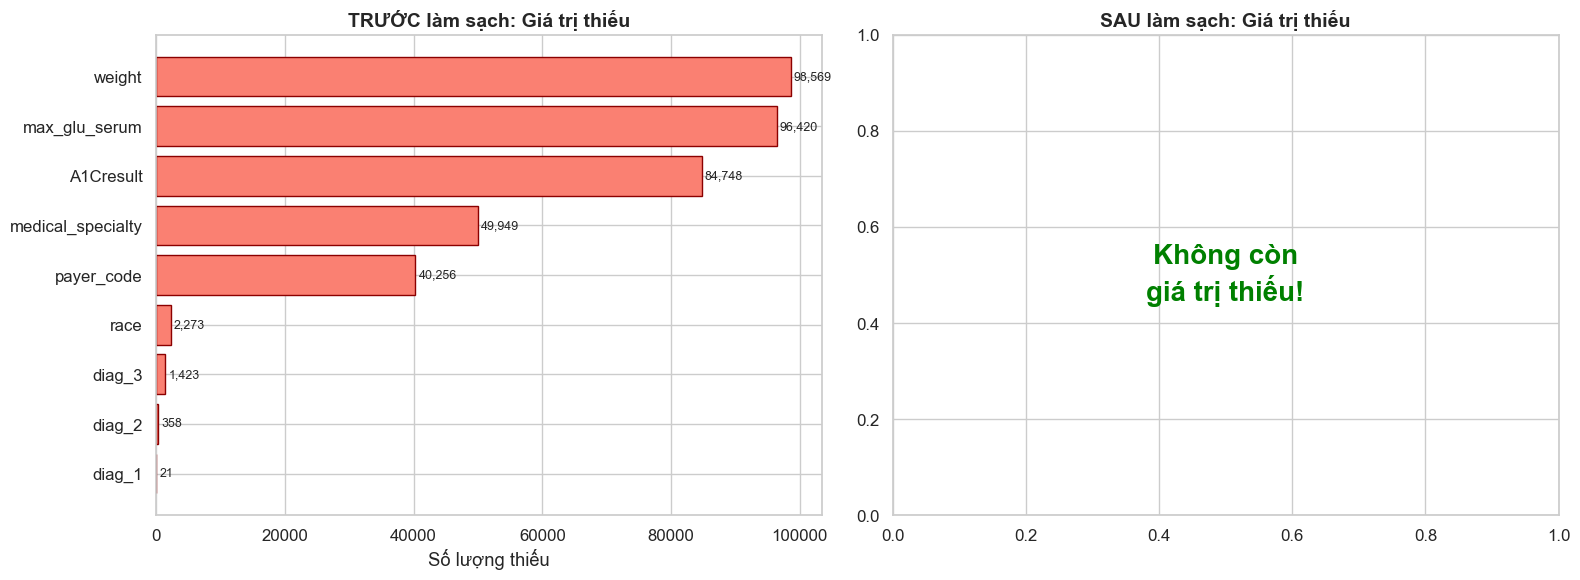

In [32]:
# Biểu đồ 1: So sánh giá trị thiếu TRƯỚC và SAU
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Trước
cols_missing = missing_before[missing_before > 0].sort_values(ascending=True)
axes[0].barh(cols_missing.index, cols_missing.values, color="salmon", edgecolor="darkred")
axes[0].set_title("TRƯỚC làm sạch: Giá trị thiếu", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Số lượng thiếu")
for i, v in enumerate(cols_missing.values):
    axes[0].text(v + 500, i, f"{v:,}", va="center", fontsize=9)

# Sau
after_missing = clean_df.isnull().sum()
after_missing = after_missing[after_missing > 0]
if len(after_missing) == 0:
    axes[1].text(0.5, 0.5, "Không còn\ngiá trị thiếu!", transform=axes[1].transAxes,
                 ha="center", va="center", fontsize=20, color="green", fontweight="bold")
    axes[1].set_title("SAU làm sạch: Giá trị thiếu", fontsize=14, fontweight="bold")
else:
    axes[1].barh(after_missing.index, after_missing.values, color="lightgreen")
    axes[1].set_title("SAU làm sạch: Giá trị thiếu", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()


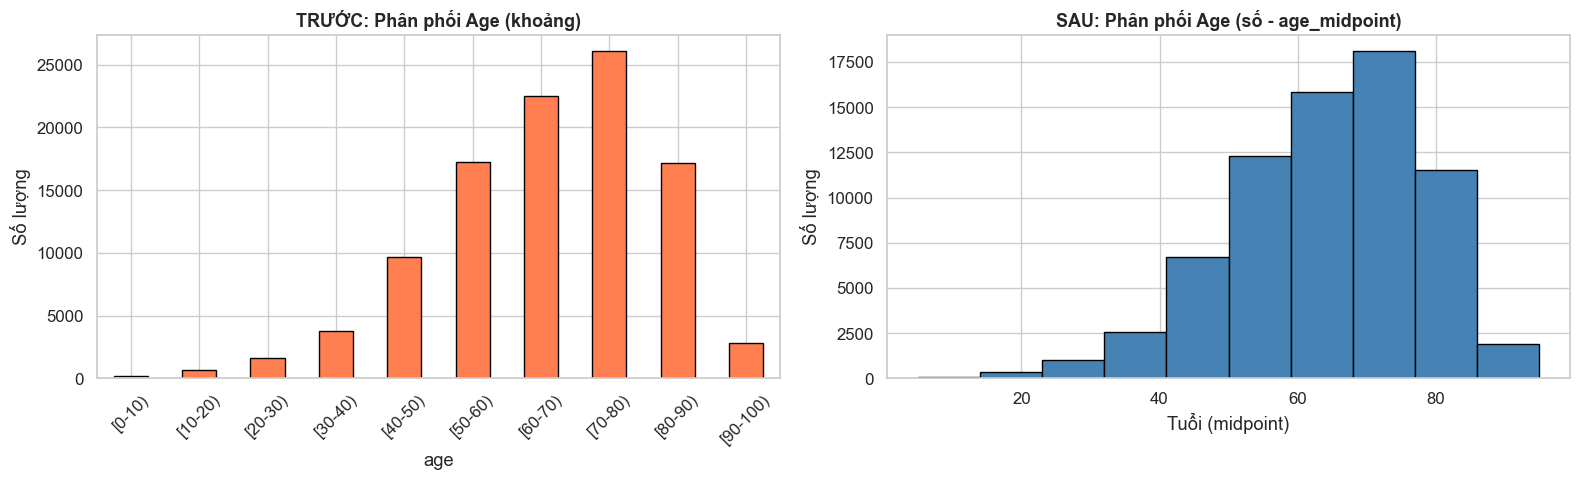

In [22]:
# Biểu đồ 2: Phân phối age – thô vs sạch
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

raw_df["age"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="coral", edgecolor="black")
axes[0].set_title("TRƯỚC: Phân phối Age (khoảng)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Số lượng")
axes[0].tick_params(axis="x", rotation=45)

clean_df["age_midpoint"].hist(bins=10, ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("SAU: Phân phối Age (số - age_midpoint)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tuổi (midpoint)")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()
plt.show()


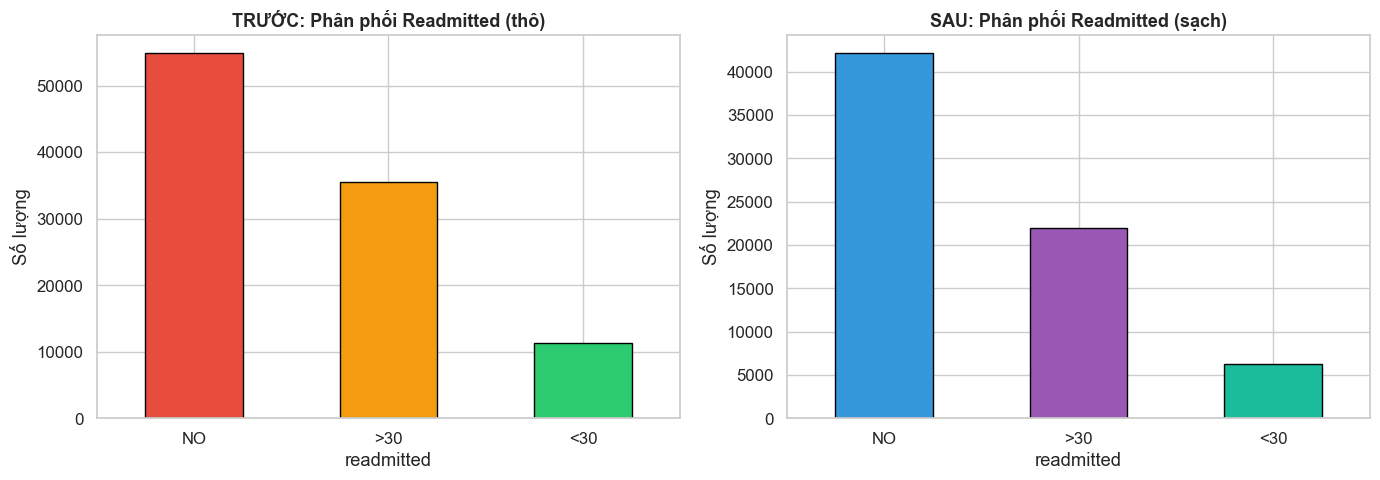

In [23]:
# Biểu đồ 3: Phân phối target (readmitted) – thô vs sạch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

raw_df["readmitted"].value_counts().plot(kind="bar", ax=axes[0], color=["#e74c3c", "#f39c12", "#2ecc71"], edgecolor="black")
axes[0].set_title("TRƯỚC: Phân phối Readmitted (thô)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Số lượng")
axes[0].tick_params(axis="x", rotation=0)

clean_df["readmitted"].value_counts().plot(kind="bar", ax=axes[1], color=["#3498db", "#9b59b6", "#1abc9c"], edgecolor="black")
axes[1].set_title("SAU: Phân phối Readmitted (sạch)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Số lượng")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


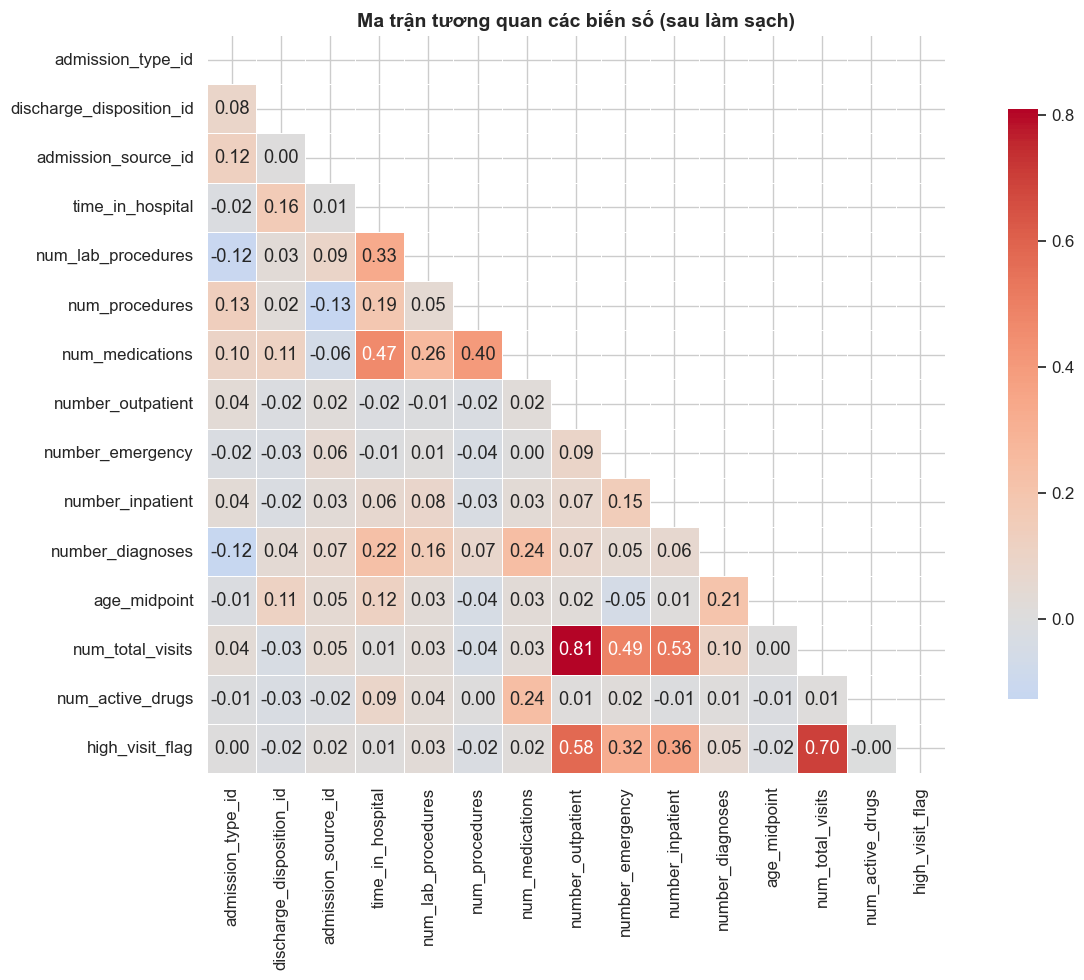

In [34]:
# Biểu đồ 4 (bonus): Heatmap tương quan các biến số
numeric_cols = clean_df.select_dtypes(include=[np.number]).columns.tolist()
corr = clean_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Ma trận tương quan các biến số (sau làm sạch)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---
## Bước 5: Chuẩn bị dữ liệu sẵn sàng mô hình hóa
> Mã hóa đặc trưng phân loại bằng one-hot encoding và thang hóa đặc trưng số.

In [25]:
# 5.1 Xác định cột phân loại và cột số
cat_cols = clean_df.select_dtypes(include="object").columns.tolist()
num_cols = clean_df.select_dtypes(include=[np.number]).columns.tolist()

# Tách target ra
if "readmitted" in cat_cols:
    cat_cols.remove("readmitted")

print(f"Cột phân loại ({len(cat_cols)}): {cat_cols}")
print(f"Cột số ({len(num_cols)}): {num_cols}")

Cột phân loại (22): ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed']
Cột số (15): ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_midpoint', 'num_total_visits', 'num_active_drugs', 'high_visit_flag']


In [26]:
# 5.2 One-Hot Encoding cho biến phân loại
model_df = clean_df.copy()

# Xóa cột age gốc (đã có age_midpoint)
if "age" in model_df.columns:
    model_df.drop(columns=["age"], inplace=True)
    cat_cols = [c for c in cat_cols if c != "age"]

model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True, dtype=int)
print(f"Sau One-Hot Encoding: {model_df.shape}")
model_df.head(3)

Sau One-Hot Encoding: (70413, 2230)


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted,age_midpoint,num_total_visits,num_active_drugs,high_visit_flag,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,diag_1_11,diag_1_110,diag_1_112,diag_1_114,diag_1_115,diag_1_117,...,glimepiride_Up,glipizide_No,glipizide_Steady,glipizide_Up,glyburide_No,glyburide_Steady,glyburide_Up,pioglitazone_No,pioglitazone_Steady,pioglitazone_Up,rosiglitazone_No,rosiglitazone_Steady,rosiglitazone_Up,acarbose_Steady,acarbose_Up,miglitol_No,miglitol_Steady,miglitol_Up,tolazamide_Steady,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,change_No,diabetesMed_Yes
1,1,1,7,3,59,0,18,0,0,0,9,>30,15,0,1,0,0,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,1
2,1,1,7,2,11,5,13,2,0,1,6,NO,25,3,1,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,1
3,1,1,7,2,44,1,16,0,0,0,7,NO,35,0,1,0,0,1,0,0,1,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,1


In [27]:
# 5.3 Chuẩn hóa (Standardization) cho biến số
from sklearn.preprocessing import StandardScaler

# Không scale target
num_to_scale = [c for c in num_cols if c in model_df.columns]
scaler = StandardScaler()
model_df[num_to_scale] = scaler.fit_transform(model_df[num_to_scale])

print("Sau chuẩn hóa (mean ≈ 0, std ≈ 1):")
model_df[num_to_scale].describe().round(2)

Sau chuẩn hóa (mean ≈ 0, std ≈ 1):


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_midpoint,num_total_visits,num_active_drugs,high_visit_flag
count,70413.00,70413.00,70413.00,70413.00,70413.00,70413.00,70413.00,70413.00,70413.00,70413.00,70413.00,70413.00,70413.00,70413.00,70413.00
mean,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.73,-0.49,-1.12,-1.12,-2.11,-0.82,-1.78,-0.26,-0.20,-0.30,-2.29,-3.91,-0.40,-1.26,-0.15
25%,-0.73,-0.49,-1.12,-0.78,-0.61,-0.82,-0.70,-0.26,-0.20,-0.30,-0.70,-0.71,-0.40,-0.19,-0.15
50%,-0.73,-0.49,0.32,-0.11,0.04,-0.25,-0.22,-0.26,-0.20,-0.30,0.35,-0.06,-0.40,-0.19,-0.15
75%,0.60,-0.12,0.32,0.57,0.69,0.31,0.50,-0.26,-0.20,-0.30,0.88,0.58,0.30,0.87,-0.15
max,3.91,4.63,4.64,3.27,4.45,2.58,7.85,38.79,81.89,19.43,4.58,1.86,33.63,5.11,6.64


In [28]:
# 5.4 Mã hóa target: readmitted → số
target_map = {"NO": 0, ">30": 1, "<30": 2}
model_df["readmitted"] = model_df["readmitted"].map(target_map)
print("Phân phối target sau mã hóa:")
print(model_df["readmitted"].value_counts().sort_index())
print("  0 = NO, 1 = >30 ngày, 2 = <30 ngày")

Phân phối target sau mã hóa:
readmitted
0    42145
1    22018
2     6250
Name: count, dtype: int64
  0 = NO, 1 = >30 ngày, 2 = <30 ngày


---
## Lưu bộ dữ liệu sạch

In [29]:
# Lưu bộ dữ liệu đã làm sạch (chưa encoding)
Path("outputs").mkdir(exist_ok=True)
clean_df.to_csv("outputs/diabetic_data_clean.csv", index=False)
print(f"Đã lưu: outputs/diabetic_data_clean.csv ({clean_df.shape})")

# Lưu bộ dữ liệu sẵn sàng cho mô hình (đã encoding + scaling)
model_df.to_csv("outputs/diabetic_data_model_ready.csv", index=False)
print(f"Đã lưu: outputs/diabetic_data_model_ready.csv ({model_df.shape})")

Đã lưu: outputs/diabetic_data_clean.csv ((70413, 38))
Đã lưu: outputs/diabetic_data_model_ready.csv ((70413, 2230))


---
## Từ điển dữ liệu (Data Dictionary)

In [37]:
# Tạo từ điển dữ liệu cho bộ sạch
dict_rows=[]
for col in clean_df.columns:
    dtype = str(clean_df[col].dtype)
    nuniq = clean_df[col].nunique()
    missing = clean_df[col].isnull().sum()
    if clean_df[col].dtype in [np.float64, np.int64]:
        sample = f"min={clean_df[col].min()}, max={clean_df[col].max()}"
    else:
        top3 = clean_df[col].value_counts().head(3).index.tolist()
        sample = ", ".join(str(x) for x in top3)
    is_new = "-- Mới" if col in ["age_midpoint", "num_total_visits", "num_active_drugs", "high_visit_flag"] else ""
    dict_rows.append([col, dtype, nuniq, missing, sample, is_new])

data_dict = pd.DataFrame(dict_rows, columns=["Cột", "Kiểu", "Unique", "Thiếu", "Mẫu giá trị", "Ghi chú"])
data_dict.to_csv("outputs/data_dictionary.csv", index=False)
print("Đã lưu: outputs/data_dictionary.csv")
data_dict

Đã lưu: outputs/data_dictionary.csv


,Cột,Kiểu,Unique,Thiếu,Mẫu giá trị,Ghi chú
0,race,object,5,0,"Caucasian, AfricanAmerican, Other",
1,gender,object,2,0,"Female, Male",
2,age,object,10,0,"[70-80), [60-70), [50-60)",
3,admission_type_id,int64,8,0,"min=1, max=8",
4,discharge_disposition_id,int64,26,0,"min=1, max=28",
5,admission_source_id,int64,17,0,"min=1, max=25",
6,time_in_hospital,int64,14,0,"min=1, max=14",
7,num_lab_procedures,int64,116,0,"min=1, max=132",
8,num_procedures,int64,7,0,"min=0, max=6",
9,num_medications,int64,75,0,"min=1, max=81",


---
## Tổng kết

| Hạng mục | Trước | Sau |
|----------|-------|-----|
| Số dòng | 101,766 | ~71,000 (sau xóa trùng + dòng lỗi) |
| Số cột | 50 | ~35 (sau xóa cột thiếu/zero-variance) |
| Giá trị thiếu | 9 cột có thiếu | 0 |
| Đặc trưng mới | 0 | 4 (age_midpoint, num_total_visits, num_active_drugs, high_visit_flag) |

**Các file output:**
- `outputs/diabetic_data_clean.csv` – Dữ liệu đã làm sạch
- `outputs/diabetic_data_model_ready.csv` – Dữ liệu sẵn sàng cho mô hình (đã encoding + scaling)
- `outputs/data_dictionary.csv` – Từ điển dữ liệu
